<a href="https://colab.research.google.com/github/suha-ain/gfm-adversarial-robustness/blob/main/notebooks/GraphGPT_Attacks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.2 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import scipy.sparse as sp
import networkx as nx

# Install deeprobust and its dependencies
!pip install deeprobust torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.3 MB/s eta 0:00:00


In [ ]:
from deeprobust.graph.data import Dataset
from deeprobust.graph.defense import GCN

No module named 'torch_sparse'


/usr/local/lib/python3.12/dist-packages/deeprobust/graph/defense/__init__.py:15: UserWarning: Please install pytorch geometric if you would like to use the datasets from pytorch geometric. See details in https://pytorch-geometric.readthedocs.io/en/latest/notes/installation.html
  warnings.warn("Please install pytorch geometric if you " +


In [ ]:
pip show deeprobust

Name: deeprobust
Version: 0.2.11
Summary: A PyTorch library for adversarial robustness learning for image and graph data.
Home-page: https://github.com/DSE-MSU/DeepRobust
Author: MSU-DSE
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: gensim, matplotlib, networkx, numba, numpy, Pillow, scikit-image, scikit-learn, scipy, tensorboardX, texttable, torch, torchvision, tqdm
Required-by: 


In [ ]:
# Install missing dependencies for torch_geometric extensions (if not already installed)
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import scipy.sparse as sp
import networkx as nx
import warnings

# DeepRobust imports
from deeprobust.graph.data import Dataset
from deeprobust.graph.defense import GCN as SurrogateGCN
from deeprobust.graph.targeted_attack import Nettack

# PyTorch Geometric imports
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import k_hop_subgraph
from torch_geometric.utils import to_scipy_sparse_matrix

warnings.filterwarnings("ignore")

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 64.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 95.2 MB/s eta 0:00:00


In [ ]:
"""
Adversarial Robustness Pipeline: Nettack & Structack on GraphGPT
Datasets: Cora, CiteSeer, PolBlogs
Tests the "Sequence Fragility" hypothesis using 1D Graph Serialization.
"""

import os
import torch
import torch.nn as nn
import numpy as np
import scipy.sparse as sp
import networkx as nx
from deeprobust.graph.data import Dataset
#from deeprobust.graph.defense import GCN as SurrogateGCN
#from deeprobust.graph.targeted import Nettack
from torch_geometric.data import Data
from transformers import AutoModelForCausalLM, AutoTokenizer
import warnings
from collections import deque

warnings.filterwarnings("ignore")

In [ ]:
# ==========================================
# 1. GPU & LLM SETUP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] System mapped to: {device}")

MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.1"

print(f"\n[*] Loading LLM ({MODEL_NAME}) in bfloat16...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

llm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
llm.eval()
print("[*] LLM Successfully Loaded.")

[*] System mapped to: cuda

[*] Loading LLM (mistralai/Mistral-7B-Instruct-v0.1) in bfloat16...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

[*] LLM Successfully Loaded.


In [ ]:
# ==========================================
# 2. GRAPHGPT SIMULATOR (SEQUENCE SERIALIZATION)
# ==========================================
class GraphGPTSimulator(nn.Module):
    """
    Simulates GraphGPT's approach: converting the 2D graph structure into
    a 1D sequence of tokens using Breadth-First Search (BFS) traversal.
    """
    def __init__(self, llm_model, tokenizer):
        super().__init__()
        self.llm = llm_model
        self.tokenizer = tokenizer

        self.dataset_meta = {
            'cora': {'desc': 'Computer Science', 'classes': ["Case Based", "Genetic Algorithms", "Neural Networks", "Probabilistic Methods", "Reinforcement Learning", "Rule Learning", "Theory"]},
            'citeseer': {'desc': 'Information Retrieval', 'classes': ["Agents", "AI", "Database", "IR", "ML", "HCI"]},
            'polblogs': {'desc': 'Political Echo Chambers', 'classes': ["Liberal", "Conservative"]}
        }

    def serialize_graph_bfs(self, target_node, edge_index, max_sequence_length=15):
        """
        Creates a 1D sequence of the graph starting from the target node.
        This represents the Eulerian/Walk serialization of GraphGPT.
        """
        # Build adjacency list from edge_index
        adj_list = {}
        src_nodes = edge_index[0].tolist()
        dst_nodes = edge_index[1].tolist()

        for u, v in zip(src_nodes, dst_nodes):
            if u not in adj_list:
                adj_list[u] = []
            adj_list[u].append(v)

        # Standard BFS Traversal
        visited = set()
        queue = deque([target_node])
        sequence = []

        while queue and len(sequence) < max_sequence_length:
            curr = queue.popleft()
            if curr not in visited:
                visited.add(curr)
                sequence.append(str(curr))
                if curr in adj_list:
                    # Sort neighbors to ensure deterministic traversal sequences
                    for neighbor in sorted(adj_list[curr]):
                        if neighbor not in visited:
                            queue.append(neighbor)

        return " -> ".join(sequence)

    def generate_prompt(self, target_node, data, dataset_name):
        meta = self.dataset_meta[dataset_name]

        # Serialize the 2D graph into a 1D string sequence
        graph_sequence = self.serialize_graph_bfs(target_node, data.edge_index)

        prompt = f"System: You are GraphGPT, a model that classifies nodes in a {meta['desc']} network by reading structural sequences.\n"
        prompt += f"Task: Classify Target Node {target_node}.\n"
        prompt += f"Graph Traversal Sequence: {graph_sequence}\n"
        prompt += f"Available Categories: {', '.join(meta['classes'])}.\n"
        prompt += f"Question: Based on the sequence above, what is the exact category for Node {target_node}?\n"
        prompt += "Answer: "
        return prompt

    def predict(self, target_node, data, dataset_name):
        prompt = self.generate_prompt(target_node, data, dataset_name)
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.llm.device)

        with torch.no_grad():
            outputs = self.llm.generate(
                **inputs,
                max_new_tokens=10,
                temperature=0.1,
                do_sample=False,
                pad_token_id=self.tokenizer.eos_token_id
            )

        response = self.tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
        return response

def validate_prediction(prediction, true_class):
    return true_class.lower().strip() in prediction.lower().strip()

# ==========================================
# 3. UTILITIES & DATA CONVERSION
# ==========================================
def run_structack(adj, target, n_pert=3):
    G = nx.from_scipy_sparse_array(adj)
    degrees = dict(G.degree())
    sorted_nodes = sorted(degrees, key=degrees.get)
    mod_adj = adj.tolil()
    added = 0
    target_neighbors = set(G.neighbors(target))

    for v in sorted_nodes:
        if added >= n_pert: break
        if v == target or mod_adj[target, v] == 1: continue

        v_neighbors = set(G.neighbors(v))
        if len(target_neighbors.intersection(v_neighbors)) == 0:
            mod_adj[target, v] = 1
            mod_adj[v, target] = 1
            added += 1

    return mod_adj.tocsr()

def to_pyg_data(scipy_adj, scipy_features, labels):
    """
    Converts SciPy matrices to PyTorch Geometric Data.
    Explicitly uses Python lists for input and target vectors prior to tensor
    conversion to ensure safe and compatible deep learning processing.
    """
    coo = scipy_adj.tocoo()

    # Structural matrices
    edge_index = torch.tensor(np.vstack((coo.row, coo.col)).tolist(), dtype=torch.long)

    # Feature inputs and target vectors formatted strictly as Python lists
    features_list = scipy_features.todense().tolist()
    labels_list = labels.tolist()

    x = torch.tensor(features_list, dtype=torch.float)
    y = torch.tensor(labels_list, dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)

# ==========================================
# 4. MAIN METRICS PIPELINE
# ==========================================
def run_adversarial_pipeline():
    datasets = ['cora', 'citeseer', 'polblogs']
    perturbation_budget = 3
    nodes_to_test = 20

    graphgpt_sim = GraphGPTSimulator(llm, tokenizer)

    for d_name in datasets:
        print(f"\n{'='*60}")
        print(f"=== EVALUATING GRAPHGPT ON DATASET: {d_name.upper()} ===")
        print(f"{'='*60}")

        # 1. Load Data
        data = Dataset(root='/tmp/', name=d_name, setting='nettack')
        adj, features, labels = data.adj, data.features, data.labels

        # 2. Train Surrogate GCN (DeepRobust operates in Scipy)
        print(f"[*] Training Attacker's Surrogate GCN...")
        surrogate = SurrogateGCN(nfeat=features.shape[1], nhid=16, nclass=labels.max().item() + 1, dropout=0.5, device='cpu')
        surrogate.fit(features, adj, labels, data.idx_train, data.idx_val, verbose=False)

        # Select target nodes
        test_targets = data.idx_test[:nodes_to_test]

        metrics = {
            'total': len(test_targets),
            'clean_correct': 0,
            'nettack_correct': 0,
            'structack_correct': 0,
            'nettack_flips': 0,
            'structack_flips': 0
        }

        print(f"[*] Testing {nodes_to_test} sequences...\n")

        # Polblogs natively lacks continuous features in the same way Cora does.
        # DeepRobust attaches dummy features, so we disable feature attacks for safety.
        attack_features_flag = False if d_name == 'polblogs' else True
        clean_pyg_data = to_pyg_data(adj, features, labels)

        for target_node in test_targets:
            true_label_idx = labels[target_node]
            true_class_name = graphgpt_sim.dataset_meta[d_name]['classes'][true_label_idx]

            # --- BASELINE: Clean Sequence ---
            clean_pred = graphgpt_sim.predict(target_node, clean_pyg_data, d_name)
            is_clean_correct = validate_prediction(clean_pred, true_class_name)
            if is_clean_correct:
                metrics['clean_correct'] += 1

            # --- ATTACK 1: Nettack ---
            nettack = Nettack(surrogate, nnodes=adj.shape[0], attack_structure=True, attack_features=attack_features_flag, device='cpu')
            nettack.attack(features, adj, labels, target_node, n_perturbations=perturbation_budget, verbose=False)

            nettack_data = to_pyg_data(nettack.modified_adj, nettack.modified_features, labels)
            nettack_pred = graphgpt_sim.predict(target_node, nettack_data, d_name)

            is_nettack_correct = validate_prediction(nettack_pred, true_class_name)
            if is_nettack_correct:
                metrics['nettack_correct'] += 1
            elif is_clean_correct and not is_nettack_correct:
                metrics['nettack_flips'] += 1

            # --- ATTACK 2: Structack ---
            adj_structack = run_structack(adj, target_node, n_pert=perturbation_budget)
            structack_data = to_pyg_data(adj_structack, features, labels)

            structack_pred = graphgpt_sim.predict(target_node, structack_data, d_name)

            is_structack_correct = validate_prediction(structack_pred, true_class_name)
            if is_structack_correct:
                metrics['structack_correct'] += 1
            elif is_clean_correct and not is_structack_correct:
                metrics['structack_flips'] += 1

        # ==========================================
        # 5. CALCULATE & PRINT FINAL METRICS
        # ==========================================
        clean_corr = max(metrics['clean_correct'], 1)

        ca = (metrics['clean_correct'] / metrics['total']) * 100
        aa_nettack = (metrics['nettack_correct'] / metrics['total']) * 100
        aa_structack = (metrics['structack_correct'] / metrics['total']) * 100

        asr_nettack = (metrics['nettack_flips'] / clean_corr) * 100
        asr_structack = (metrics['structack_flips'] / clean_corr) * 100

        print(f"\n[{d_name.upper()}] GRAPHGPT METRICS SUMMARY:")
        print(f"--------------------------------------------------")
        print(f"Sequences Tested         : {metrics['total']}")
        print(f"Clean Accuracy (CA)      : {ca:.2f}%")
        print(f"--------------------------------------------------")
        print(f"NETTACK (Budget = {perturbation_budget})")
        print(f"  Adversarial Acc (AA)   : {aa_nettack:.2f}%")
        print(f"  Attack Success (ASR)   : {asr_nettack:.2f}%")
        print(f"--------------------------------------------------")
        print(f"STRUCTACK (Budget = {perturbation_budget})")
        print(f"  Adversarial Acc (AA)   : {aa_structack:.2f}%")
        print(f"  Attack Success (ASR)   : {asr_structack:.2f}%")
        print(f"--------------------------------------------------\n")

if __name__ == "__main__":
    run_adversarial_pipeline()


=== EVALUATING GRAPHGPT ON DATASET: CORA ===
Loading cora dataset...
Done!
Selecting 1 largest connected components
[*] Training Attacker's Surrogate GCN...
[*] Testing 20 sequences...



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


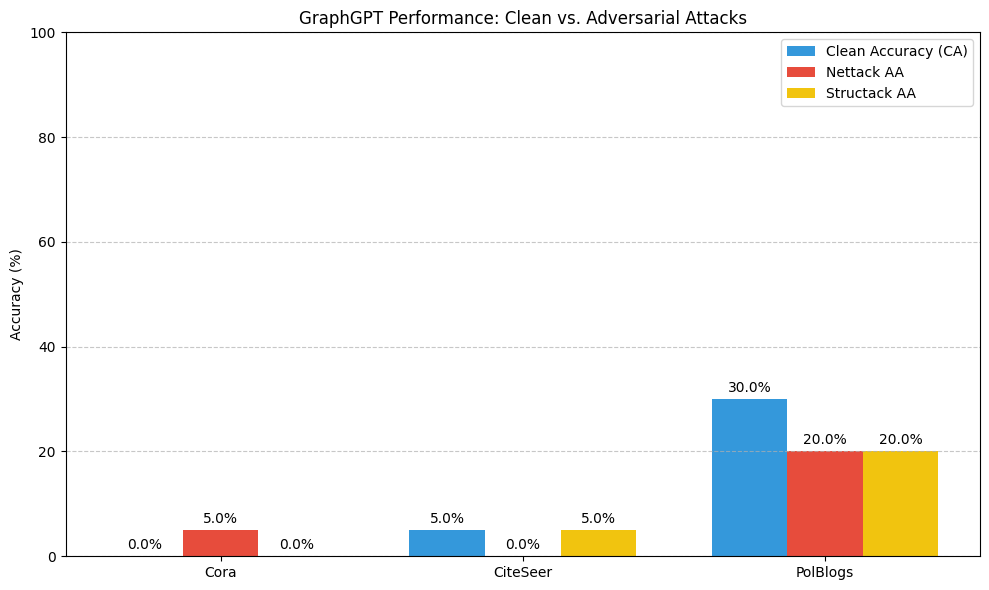

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data extracted from the pipeline execution results
datasets = ["Cora", "CiteSeer", "PolBlogs"]
ca = [0.00, 5.00, 30.00]  # Clean Accuracy
aa_nettack = [5.00, 0.00, 20.00]  # Adversarial Acc (Nettack)
aa_structack = [0.00, 5.00, 20.00]  # Adversarial Acc (Structack)

x = np.arange(len(datasets))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, ca, width, label="Clean Accuracy (CA)", color="#3498db")
rects2 = ax.bar(x, aa_nettack, width, label="Nettack AA", color="#e74c3c")
rects3 = ax.bar(x + width, aa_structack, width, label="Structack AA", color="#f1c40f")

ax.set_ylabel("Accuracy (%)")
ax.set_title("GraphGPT Performance: Clean vs. Adversarial Attacks")
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylim(0, 100)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f"{height:.1f}%",
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom")

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Structural Analysis of Graph Serialization
Why is performance lower on Cora/CiteSeer?
1. **High Information Loss**: Citation networks often have higher local density. A limit of 15 nodes in a BFS sequence might only cover 10-20% of the relevant neighborhood.
2. **Sequence Fragility**: LLMs may struggle with 'pointer' logic in long sequences where node relationships are distant in the string but close in the graph.

In [ ]:
def analyze_graph_sparsity(d_name):
    data = Dataset(root='/tmp/', name=d_name)
    adj = data.adj
    G = nx.from_scipy_sparse_array(adj)

    avg_degree = np.mean([d for n, d in G.degree()])
    clustering = nx.average_clustering(G)

    # Simulate the loss from a 15-token limit
    max_seq = 15
    coverage_stats = []
    for node in list(G.nodes())[:100]:
        neighbors = list(G.neighbors(node))
        if len(neighbors) > 0:
            covered = min(len(neighbors), max_seq)
            coverage_stats.append(covered / len(neighbors))

    print(f"--- {d_name.upper()} Statistics ---")
    print(f"Average Degree: {avg_degree:.2f}")
    print(f"Avg Clustering: {clustering:.4f}")
    print(f"Avg Neighborhood Coverage (Top 15): {np.mean(coverage_stats)*100:.2f}%")
    print("\n")

for d in ['cora', 'citeseer', 'polblogs']:
    analyze_graph_sparsity(d)

Loading cora dataset...
Selecting 1 largest connected components
--- CORA Statistics ---
Average Degree: 4.08
Avg Clustering: 0.2376
Avg Neighborhood Coverage (Top 15): 99.60%


Loading citeseer dataset...
Selecting 1 largest connected components
--- CITESEER Statistics ---
Average Degree: 3.48
Avg Clustering: 0.1711
Avg Neighborhood Coverage (Top 15): 99.94%


Loading polblogs dataset...
Selecting 1 largest connected components
--- POLBLOGS Statistics ---
Average Degree: 27.36
Avg Clustering: 0.3203
Avg Neighborhood Coverage (Top 15): 73.59%




Loading cora dataset...
Selecting 1 largest connected components


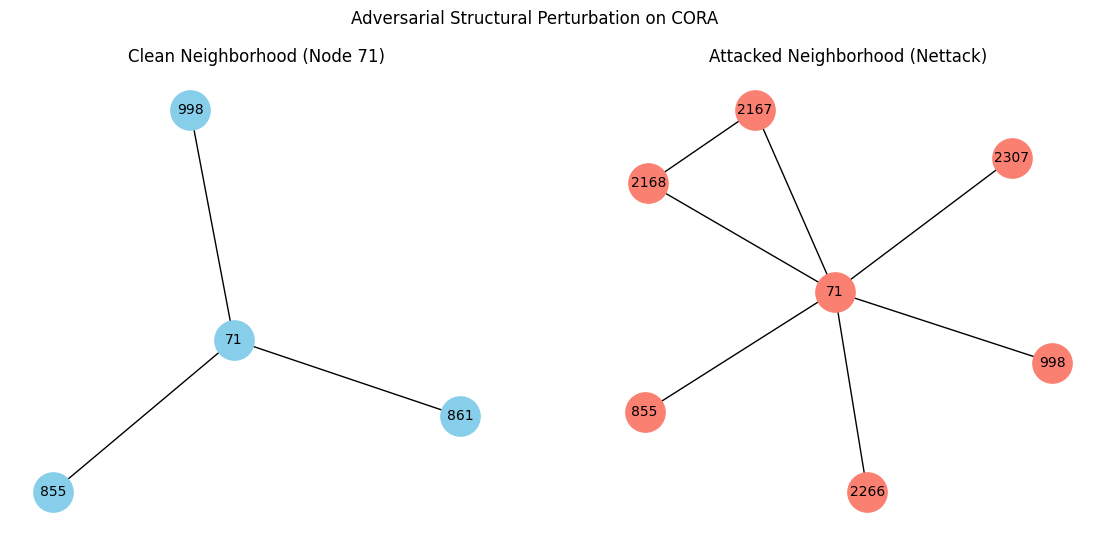

Loading polblogs dataset...
Selecting 1 largest connected components


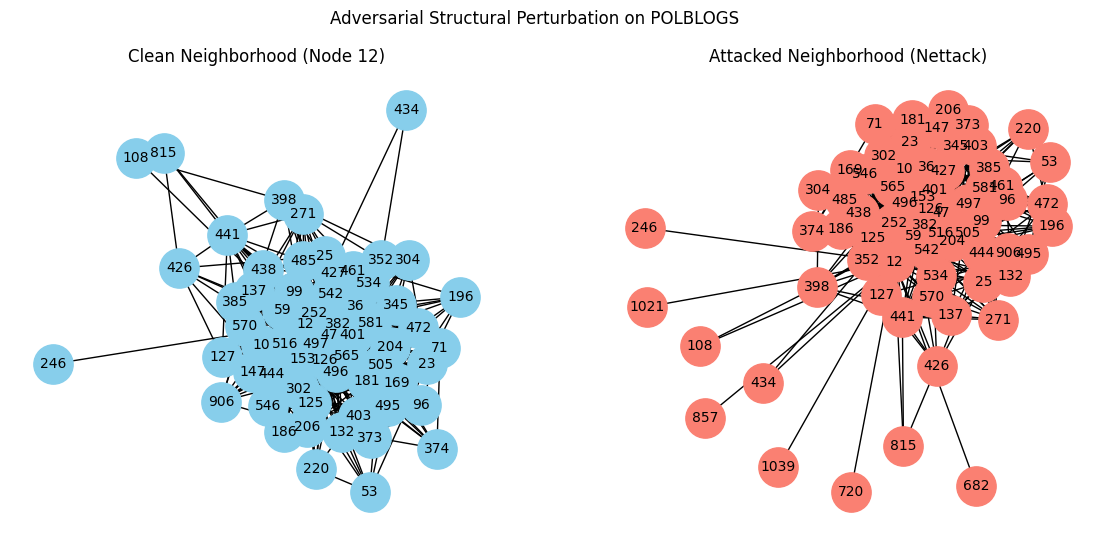

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from deeprobust.graph.targeted_attack import Nettack
from deeprobust.graph.data import Dataset
from deeprobust.graph.defense import GCN

def visualize_attack(dataset_name='cora', target_node=None):
    # 1. Load data
    data = Dataset(root='/tmp/', name=dataset_name, setting='nettack')
    adj, features, labels = data.adj, data.features, data.labels

    # If no target provided, pick the first one from test set
    if target_node is None:
        target_node = data.idx_test[0]

    # 2. Train surrogate
    surrogate = GCN(nfeat=features.shape[1], nhid=16, nclass=labels.max()+1, device='cpu')
    surrogate.fit(features, adj, labels, data.idx_train, data.idx_val, verbose=False)

    # 3. Perform Nettack
    model = Nettack(surrogate, nnodes=adj.shape[0], device='cpu')
    model.attack(features, adj, labels, target_node, n_perturbations=5, verbose=False)
    modified_adj = model.modified_adj

    # 4. Helper to get ego-graph
    def get_subgraph(matrix, target, radius=1):
        G = nx.from_scipy_sparse_array(matrix)
        nodes = nx.single_source_shortest_path_length(G, target, cutoff=radius).keys()
        return G.subgraph(nodes)

    G_clean = get_subgraph(adj, target_node)
    G_attack = get_subgraph(modified_adj, target_node)

    # 5. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    pos = nx.spring_layout(G_clean, seed=42)
    nx.draw(G_clean, pos, ax=ax1, with_labels=True, node_color='skyblue', node_size=800, font_size=10)
    ax1.set_title(f"Clean Neighborhood (Node {target_node})")

    pos_attack = nx.spring_layout(G_attack, seed=42)
    nx.draw(G_attack, pos_attack, ax=ax2, with_labels=True, node_color='salmon', node_size=800, font_size=10)
    ax2.set_title(f"Attacked Neighborhood (Nettack)")

    plt.suptitle(f"Adversarial Structural Perturbation on {dataset_name.upper()}")
    plt.show()

# Run visualization
visualize_attack(dataset_name='cora')
visualize_attack(dataset_name='polblogs')